In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('28-urban_pedestrian_locations_with_labels.csv')

df.head()

,x_position,y_position,true_cluster
0,0.830586,-0.447733,1
1,0.701678,0.816918,0
2,1.022080,-0.492571,1
3,-0.316765,0.953438,0
4,0.293226,1.057185,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   x_position    500 non-null    float64
 1   y_position    500 non-null    float64
 2   true_cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


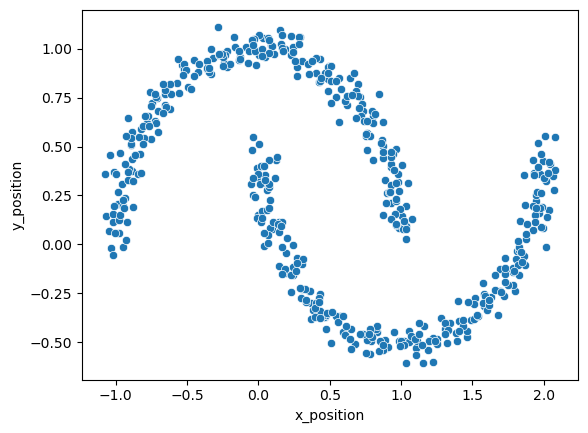

In [4]:
sns.scatterplot(data = df , x = 'x_position' , y = 'y_position')
plt.show()

In [5]:
df.drop(columns = 'true_cluster' , inplace = True , axis = 1 )
df.head()

,x_position,y_position
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [7]:
from sklearn.cluster import DBSCAN

In [8]:
dbscan = DBSCAN()

dbscan.fit(X_scaled)

DBSCAN()

In [9]:
dbscan.labels_

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,

In [10]:
X_scaled = pd.DataFrame(X_scaled , columns = ['x_position' , 'y_position'])

In [11]:
clusters = pd.DataFrame(dbscan.labels_)
X_scaled['clusters'] = clusters

In [12]:
X_scaled

,x_position,y_position,clusters
0,0.375125,-1.403679,0
1,0.226815,1.135628,1
2,0.595442,-1.493710,0
3,-0.944918,1.409748,1
4,-0.243115,1.618062,1
...,...,...,...
495,-0.304636,1.474047,1
496,-0.497472,-0.133542,0
497,0.098642,-1.238718,0
498,1.282741,-1.074231,0


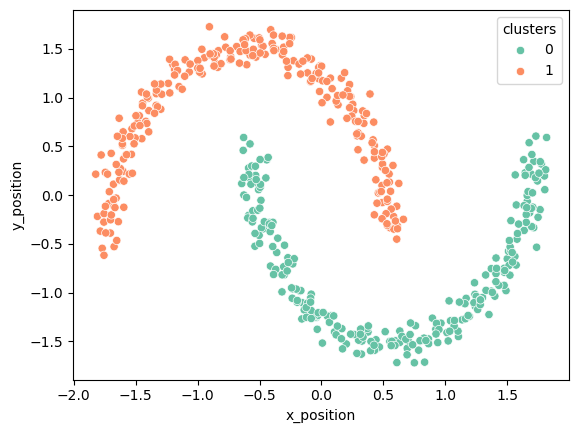

In [13]:
sns.scatterplot(data = X_scaled , x = 'x_position' , y = 'y_position' , hue = 'clusters' , palette = 'Set2')
plt.show()

In [14]:
from sklearn.cluster import AgglomerativeClustering

In [15]:
new_df = X_scaled.drop(columns = 'clusters' , axis = 1)

In [16]:
aglo = AgglomerativeClustering(n_clusters = 2 , linkage = 'single')

preds = aglo.fit_predict(new_df)

In [17]:
new_df['preds'] = pd.DataFrame(preds)

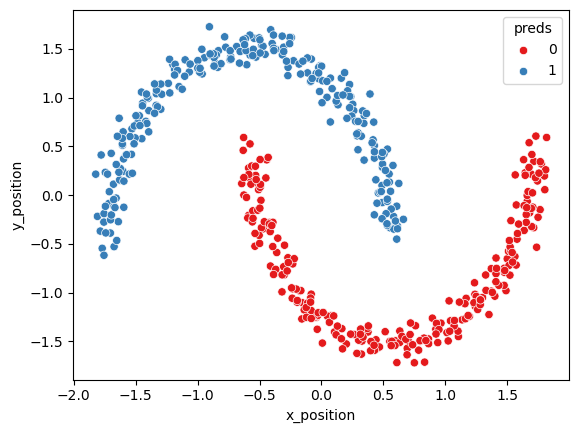

In [18]:
sns.scatterplot(data = new_df , x = 'x_position' , y = 'y_position' , hue = 'preds' , palette = 'Set1')
plt.show()

In [19]:
# Hyperparmether Tuning

In [20]:
df = pd.read_csv('28-urban_pedestrian_locations_with_labels.csv')

df.drop(columns = 'true_cluster' , inplace = True , axis = 1 )

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)


In [21]:
from sklearn.metrics import silhouette_score

eps_values = [0.2 , 0.3 , 0.4 , 0.5 , 0.6] 
min_samples_values = [3, 4 ,5 , 6]

result = []

for eps in eps_values : 
    for min_samples in min_samples_values : 
        dbscan = DBSCAN(eps = eps , min_samples = min_samples)
        dbscan.fit(X_scaled)
        labels = dbscan.labels_

        if len(set(labels)) <= 1 : 
            continue 

        result.append(
            {
                    'EPS' : eps , 
                    'Min Samples Value' : min_samples, 
                    'silhouette' : silhouette_score(X_scaled , labels),
                    'n_clusters' : len(set(labels))
            }
            )

result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by = 'silhouette' , ascending = False)

In [22]:
result_df

,EPS,Min Samples Value,silhouette,n_clusters
0,0.2,3,0.389338,2
1,0.2,4,0.389338,2
2,0.2,5,0.389338,2
3,0.2,6,0.389338,2
4,0.3,3,0.389338,2
5,0.3,4,0.389338,2
6,0.3,5,0.389338,2
7,0.3,6,0.389338,2
8,0.4,3,0.389338,2
9,0.4,4,0.389338,2


In [23]:
# HDBSCAN

In [24]:
from sklearn.cluster import HDBSCAN

In [25]:
hdbscan = HDBSCAN()

In [27]:
X_scaled = pd.DataFrame(data = X_scaled , columns = ['x_position' , 'y_position'])
X_scaled

,x_position,y_position
0,0.375125,-1.403679
1,0.226815,1.135628
2,0.595442,-1.493710
3,-0.944918,1.409748
4,-0.243115,1.618062
...,...,...
495,-0.304636,1.474047
496,-0.497472,-0.133542
497,0.098642,-1.238718
498,1.282741,-1.074231


In [28]:
hdbscan.fit(X_scaled)

HDBSCAN()

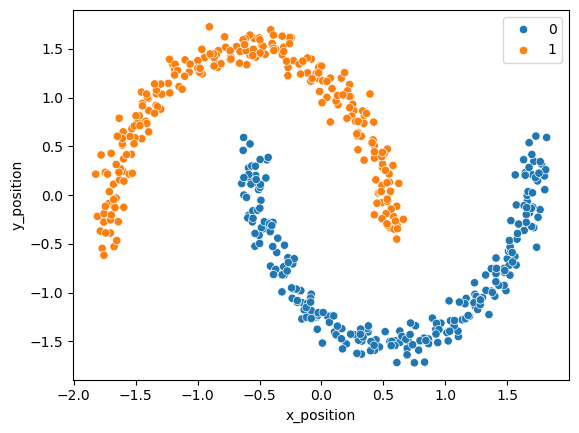

In [30]:
sns.scatterplot(data = X_scaled , x = 'x_position' , y = 'y_position' , hue = hdbscan.labels_)
plt.show()

In [32]:
# HyperParamether tuning 

In [34]:
min_cluster_size = [5 , 7 , 9 , 10]
min_samples = [None , 3 , 5 , 7 ,10]

result = []

for min_clus_size in min_cluster_size : 
    for min_samp in min_samples : 
        hdbscan = HDBSCAN(min_cluster_size = min_clus_size , min_samples = min_samp)
        hdbscan.fit(X_scaled)
        labels = hdbscan.labels_

        if(len(set(labels)) <= 1 ):
            continue
        
        result.append({
            'silhouette' : silhouette_score(X_scaled , labels),
            'Min_Cluster_Size' : min_clus_size , 
            'n_Clusters' : len(set(labels)) - (1 if -1 in labels else 0 ),
            'Min_Samples' : min_samp
        })

result_df = pd.DataFrame(data = result)
result_df = result_df.sort_values(by = 'silhouette' , ascending = False)

In [35]:
result_df 

,silhouette,Min_Cluster_Size,n_Clusters,Min_Samples
0,0.389338,5,2,NaN
1,0.389338,5,2,3.0
2,0.389338,5,2,5.0
3,0.389338,5,2,7.0
4,0.389338,5,2,10.0
5,0.389338,7,2,NaN
6,0.389338,7,2,3.0
7,0.389338,7,2,5.0
8,0.389338,7,2,7.0
9,0.389338,7,2,10.0
